In [1]:
from energymanagementrl.solar_simulation.main import run_energy_production_prediction, analyze_production, WeatherType
from energymanagementrl.solar_simulation.simulation import PanelModel, ArrayConfig, PlantConfig

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
LAT = float(os.environ.get("LAT"))
LON = float(os.environ.get("LON"))

Coordinates: 37.5625°N, 15.0°E
Elevation: 541.0 m asl
Timezone: b'Europe/Rome' b'CET'
Total AC energy: 28.03 kWh
Max production: 4.87 kW at 2024-12-10 11:30:00+01:00
Production starts at: 2024-12-10 07:15:00+01:00, ends at: 2024-12-10 16:30:00+01:00


<Figure size 640x480 with 0 Axes>

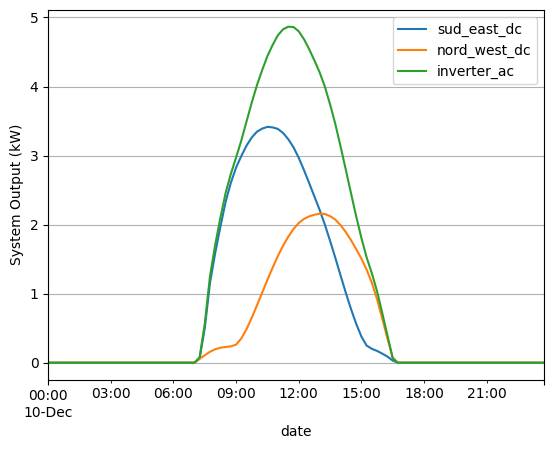

(np.float64(4.866417731545157),
 Timestamp('2024-12-10 11:30:00+0100', tz='Europe/Rome'),
 Timestamp('2024-12-10 07:15:00+0100', tz='Europe/Rome'),
 Timestamp('2024-12-10 16:30:00+0100', tz='Europe/Rome'))

In [4]:
panel_model = PanelModel(pdc0=0.42, temp_model_a=-3.56, temp_model_b=-0.075, delta_t=3, gamma_pdc=-0.004)
arrays = [ArrayConfig(name='sud_east', panel_model=panel_model, num_panels=14, tilt_angle=25, azimuth=110),
          ArrayConfig(name='nord_west', panel_model=panel_model, num_panels=14, tilt_angle=18, azimuth=290)]

plant_config = PlantConfig(
    latitude=LAT, longitude=LON, timezone='Europe/Rome', inverter_pdc0=6, arrays=arrays
)
results_df = run_energy_production_prediction(plant_config, '2024-12-10 00:00', '2024-12-10 23:55',
                                              WeatherType.open_meteo)
analyze_production(results_df)